# Counterparty exposure modelling: Longstaff–Schwartz vs Tsitsiklis–Van Roy

Comparison of two regression-based valuation algorithms: Longstaff–Schwartz (LSM) and Tsitsiklis–Van Roy (TVR), for computing counterparty credit exposure on a 10-year USD interest-rate portfolio consisting of a payer interest rate swap (IRS) and an Asian call option, both referencing the same underlying rate. The rate path is simulated with Black-Scholes model. Exposure profiles (Expected Positive Exposure (EPE) and the 2.5% / 97.5% quantiles) are used as the comparison metrics.

In [1]:
# imports

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

## Mark-to-market (MtM) value

The mark-to-market (MtM) value $V_t$ of an instrument at time $t$ is the conditional expected value of its remaining cash flows, discounted to $t$:

$$V_t = \mathbb{E}\Big[\sum_{t_i > t} \frac{D(0,t_i)}{D(0,t)}\,CF_i \;\Big|\; \mathcal{F}_t\Big]$$

where $CF_i$ are the instrument's cash flows at future dates $t_i$, and $D(0,t)=e^{-\rho t}$ (in this notebook $\rho=0$, so cash flows are left undiscounted). $V_t$ is a random variable - its value depends on the path's history up to $t$.

## Exposure

From the perspective of one fixed party, $V_t > 0$ means the counterparty owes us money: $V_t < 0$ means we owe the counterparty.

If the counterparty defaults at time $t$, we lose only the positive part of the MtM. The **exposure** is therefore

$$E_t = \max(V_t, 0) = V_t^+ ,$$

which is non-negative and depends on the chosen perspective: the counterparty's exposure to us is $\max(-V_t, 0)$.

### EFV

Expected Future Value (EFV) is the mean of the MtM

$$\mathrm{EFV}(t) = \mathbb{E}[V_t].$$

It is not an exposure measure, it describes where the MtM distribution is centred.

### EE

Expected Exposure (EE) is the mean of the exposure

$$\mathrm{EE}(t) = \mathbb{E}[E_t] = \mathbb{E}[\max(V_t, 0)].$$

It's often called Expected Positive Exposure (EPE), but that name also stands for the time-averaged quantity

$$\mathrm{EPE} = \frac{1}{T}\int_0^T \mathrm{EE}(t)\,dt.$$

### ENE

Expected Negative Exposure is the counterparty's expected exposure to us

$$\mathrm{ENE}(t) = \mathbb{E}[\max(-V_t, 0)].$$

Note also that $\mathrm{EE}(t) - \mathrm{ENE}(t) = \mathbb{E}[V_t] = \mathrm{EFV}(t)$.

### Quantile profiles / PFE

We also use the 2.5\% and 97.5\% quantiles of the MtM distribution

$$q_\alpha(t) = \inf\{x : \mathbb{P}(V_t \le x) \ge \alpha\}.$$

$\mathrm{PFE}_{97.5\%}(t)$ is the potential future exposure: a level that exposure does not exceed in 97.5% of scenarios. The lower quantile $q_{2.5\%}(t)$ describes the opposite tail.

In [2]:
def profiles(V):
    return dict(EE=np.maximum(V, 0).mean(0), ENE=np.maximum(-V, 0).mean(0),
                q025=np.percentile(V, 2.5, axis=0), q975=np.percentile(V, 97.5, axis=0))

## Instruments

The considered portfolio consists of two instruments: an interest rate swap (payer) and an Asian option (call).

### IRS

An interest rate swap is a derivative in which two counterparties exchange cash flows at each payment date $t_i$ (here quarterly). One party pays a fixed rate, while the other pays a floating rate. From the payer's perspective:

$$CF_i = N\tau\,(S_{t_i} - K),$$

where $N$ is the notional, $\tau$ the accrual fraction, $S_{t_i}$ is the floating rate and $K$ is the fixed rate, usually set to satisfy $V_0 = 0$.

### Asian option

In an Asian option, the payoff depends on the arithmetic average of $S_t$ over the fixing dates. The single payoff at maturity is

$$CF_T = N \max(A_T - K, 0), \qquad A_t = \frac{1}{n_t}\sum_{t_i \le t} S_{t_i},$$

where $A_t$ is the running average of fixings observed up to $t$. The value at $t<T$ depends on two state variables - the current rate $S_t$ and the running average $A_t$.

## Rate model

The rate paths are simulated with the Black–Scholes model (as a Geometric Brownian Motion):

$$dS_t = \mu S_t\,dt + \sigma S_t\,dW_t.$$

The implementation uses its discrete-time formula:

$$S_{t+\Delta t} = S_t \exp\Big[\big(\mu-\tfrac{1}{2}\sigma^2\big)\Delta t + \sigma \sqrt{\Delta t}\,Z\Big], \qquad Z\sim\mathcal{N}(0,1).$$

The log-normal distribution ensures $S_t>0$ at any time $t$.

In [3]:
S0, MU, SIGMA = 0.04, 0.0, 0.20 # USD spot rate, drift, volatility
T, STEPS_PY, FREQ_M = 10, 12, 3 # 10 years, monthly grid, cash flows/fixings every 3 months
RHO = 0.0 # discount rate (0 = no discounting, as used throughout this notebook)
NOTIONAL = 1_000_000
N_PATHS, SEED = 20_000, 7

dt = 1 / STEPS_PY
n_steps = T * STEPS_PY
grid = np.linspace(0, T, n_steps + 1) # simulation grid (121 dates)
cf_idx = np.arange(FREQ_M, n_steps + 1, FREQ_M) # payment/fixing date indices (40 dates)
tau = FREQ_M / 12 # accrual fraction for the coupon
D = np.exp(-RHO * grid) # discount factors D(0,t)

K_ASIAN = S0 # option strike (ATM)
K_SWAP = S0 * np.sum(np.exp(MU * grid[cf_idx]) * D[cf_idx]) / np.sum(D[cf_idx]) # swap par rate (ATM)

In [4]:
def simulate(n_paths, seed):
    """Rate paths (exact GBM discretization) + state variables and cash flows for both instruments."""
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal((n_paths, n_steps))
    logS = np.log(S0) + np.cumsum((MU - 0.5 * SIGMA**2) * dt + SIGMA * np.sqrt(dt) * Z, axis=1)
    S = np.column_stack([np.full(n_paths, S0), np.exp(logS)])  # (N, n_steps+1)

    # Asian option state
    fix = np.zeros(n_steps + 1); fix[cf_idx] = 1
    n_fix = np.cumsum(fix)
    A = np.cumsum(S * fix, axis=1) / np.maximum(n_fix, 1)

    # cash flows: payer swap
    CF_swap = np.zeros_like(S)
    CF_swap[:, cf_idx] = NOTIONAL * tau * (S[:, cf_idx] - K_SWAP)
    CF_asian = np.zeros_like(S)
    CF_asian[:, -1] = NOTIONAL * np.maximum(A[:, -1] - K_ASIAN, 0)
    return S, A, CF_swap, CF_asian

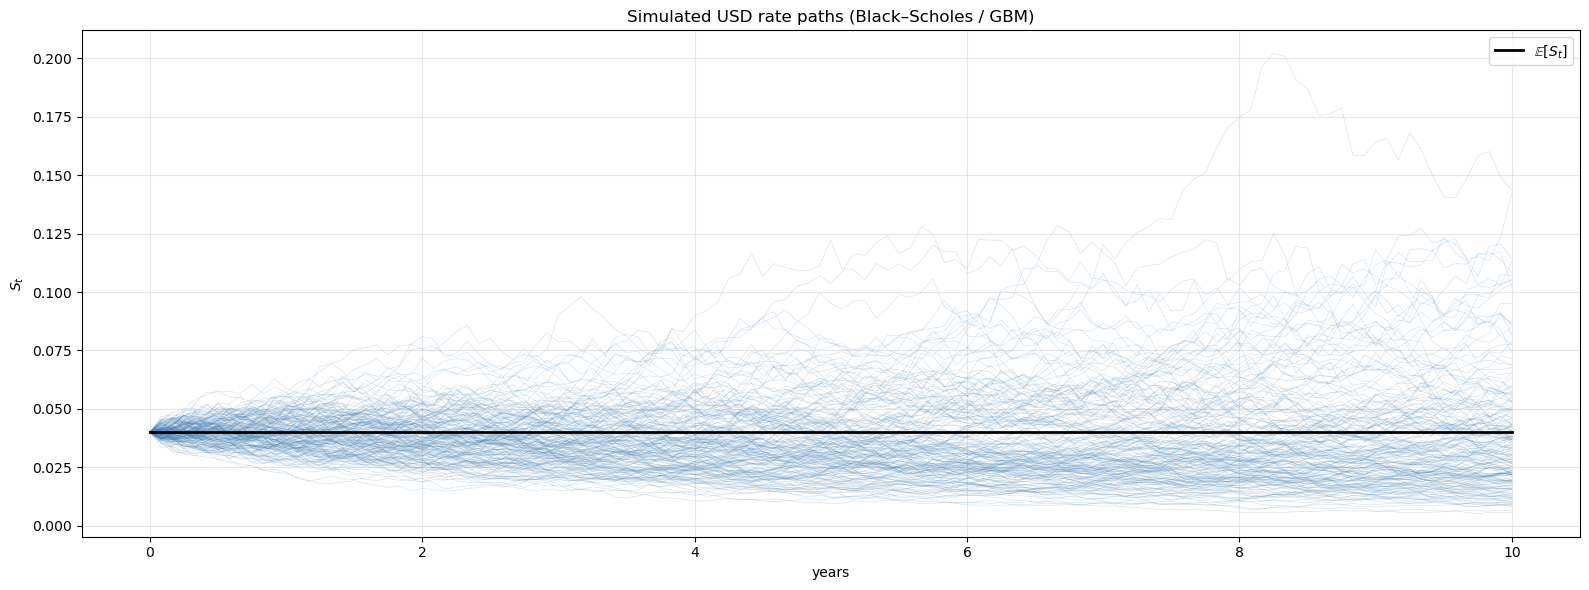

In [10]:
S, A, CF_swap, CF_asian = simulate(N_PATHS, SEED)

z = norm.ppf([0.05, 0.95])

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(grid, S[:200].T, color="steelblue", lw=0.4, alpha=0.25)
ax.plot(grid, S0 * np.exp(MU * grid), color="black", lw=2, label=r"$\mathbb{E}[S_t]$")
ax.set_title("Simulated USD rate paths (Black–Scholes / GBM)")
ax.set_xlabel("years"); ax.set_ylabel(r"$S_t$")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()

## Regression-based algorithms

As $V_t$ is a conditional expected value, computing it exactly for every path and date would require simulating the future from each one - a nested Monte Carlo approach that is computationally very expensive (used here only as a benchmark, see Validation). Instead, we approximate $V_t$ as a function of state variables ($S_t$ and, for the Asian option, $A_t$). We build a vector of basis functions $\Phi_j$ from polynomials of the current state:

$$\Phi_j = \phi(S_{t_j}, A_{t_j}),$$

and fit the approximation by least squares:

$$\hat V_{t_j} = \Phi_j \hat\beta_j, \qquad \hat\beta_j = \arg\min_\beta \sum_{\text{paths}} \big(Y - \Phi_j \beta\big)^2,$$

where $Y$ is the continuation value target, defined differently for LSM and TVR. Regression is performed separately for each date $t_j$ - coefficients $\hat\beta_j$ are not shared across dates.

In [15]:
def basis_swap(S, A, j):
    """Swap state: current rate (rescaled). Degree-2 polynomial."""
    x = S[:, j] / S0
    return np.column_stack([np.ones_like(x), x, x**2])


def basis_asian(S, A, j):
    """Option state: (rate x, running average a)."""
    n_done, n_tot = np.sum(cf_idx <= j), len(cf_idx)
    x, a = S[:, j] / S0, A[:, j] / S0
    a_hat = (n_done * a + (n_tot - n_done) * x) / n_tot
    h = np.maximum(a_hat - K_ASIAN / S0, 0)
    return np.column_stack([np.ones_like(x), x, a, x**2, a**2, x * a, h, h**2, h * x, a_hat**3])

def ols(Phi, Y):
    """OLS; lstsq handles collinearity (A_j = 0 before the first fixing)."""
    return np.linalg.lstsq(Phi, Y, rcond=None)[0]

## LSM

In the Longstaff–Schwartz approach, $Y_j$ is set to the **realized**, discounted sum of future cash flows on that path:

$$Y_j = \sum_{t_i > t_j} \frac{D(0,t_i)}{D(0,t_j)}\,CF_i.$$

The estimate $\hat V_{t_j}$ is then obtained by fitting the regression: $\hat V_{t_j} = \Phi_j \hat\beta_j$. Dates are independent - the regression at $t_j$ does not use fitted values $\hat V_{t_{j+1}}$ from other dates, only the realized cash flows on that path. Since $Y_j$ is computed directly from realized cash flows, it is unbiased estimate of $V_{t_j}$ on each path. 

In [12]:
def value_LSM(CF, basis, S, A):
    """Longstaff–Schwartz: regression, at each date j, of realized future discounted cash flows onto the state basis at j."""
    M1 = CF.shape[1]
    V, beta = np.zeros_like(CF), {}
    fut = np.cumsum((CF * D)[:, ::-1], axis=1)[:, ::-1] # sum_{i>=j} D_i*CF_i
    for j in range(1, M1 - 1):
        Y = (fut[:, j] - CF[:, j] * D[j]) / D[j] # cash flows strictly after j, valued as of j
        Phi = basis(S, A, j)
        beta[j] = ols(Phi, Y)
        V[:, j] = Phi @ beta[j]
    V[:, 0] = fut[:, 0].mean() # price at t=0 = plain MC
    return V, beta

## TVR

The Tsitsiklis–Van Roy algorithm starts at $t=T$ and proceeds backward, setting $Y_j$ as the sum of the cash flow at the next timestep and the continuation value - the fitted value $\hat V_{t_{j+1}}$ from the previous iteration of the backward loop:

$$Y_j = \frac{D(0,t_{j+1})}{D(0,t_j)}\Big(CF_{j+1} + \hat V_{t_{j+1}}\Big).$$

The target $Y_j$ contains $\hat V_{t_{j+1}}$, which means any error in that estimate propagates backward to earlier dates. As a consequence, the estimate is biased, but has lower variance across paths.

In [13]:
def value_TVR(CF, basis, S, A):
    """Tsitsiklis–Van Roy: backward induction. At date j, regress the cash flow at j+1 plus the fitted value V_{j+1}."""
    M1 = CF.shape[1]
    V, beta = np.zeros_like(CF), {}
    for j in range(M1 - 2, 0, -1):
        Y = D[j + 1] / D[j] * (CF[:, j + 1] + V[:, j + 1]) # 'tomorrow value' carried back to today
        Phi = basis(S, A, j)
        beta[j] = ols(Phi, Y)
        V[:, j] = Phi @ beta[j]
    V[:, 0] = (D[1] / D[0] * (CF[:, 1] + V[:, 1])).mean()
    return V, beta

## Results

We apply LSM and TVR from the previous section to both instruments, then combine them into the portfolio by netting the paths' MtM values:

$$V_t^{portfolio} = V_t^{swap} + V_t^{Asian}.$$

Since the option is a long position, its value cannot be negative. We floor the regression-fitted $\hat V_t$ at zero to remove this artifact.

In [16]:
S, A, CF_swap, CF_asian = simulate(N_PATHS, SEED)

V = {} # dictionary: (instrument, method) -> value matrix (N, n_steps+1)
V["swap", "LSM"], b_swap_L = value_LSM(CF_swap, basis_swap, S, A)
V["swap", "TVR"], b_swap_T = value_TVR(CF_swap, basis_swap, S, A)
V["asian", "LSM"], b_as_L = value_LSM(CF_asian, basis_asian, S, A)
V["asian", "TVR"], b_as_T = value_TVR(CF_asian, basis_asian, S, A)
for m in ("LSM", "TVR"):
    V["asian", m] = np.maximum(V["asian", m], 0) # value of long option >= 0 (cutting off regression artifact)
for m in ("LSM", "TVR"):
    V["portfolio", m] = V["swap", m] + V["asian", m] # netting: exposure from sum of MtM

print(f"K_swap(par) = {K_SWAP:.4%}, K_asian = {K_ASIAN:.4%}")
print(f"Price t=0 swap: {V['swap','LSM'][0,0]:,.0f} asian option: {V['asian','LSM'][0,0]:,.0f}")

K_swap(par) = 4.0000%, K_asian = 4.0000%
Price t=0 swap: -1,138 asian option: 5,801


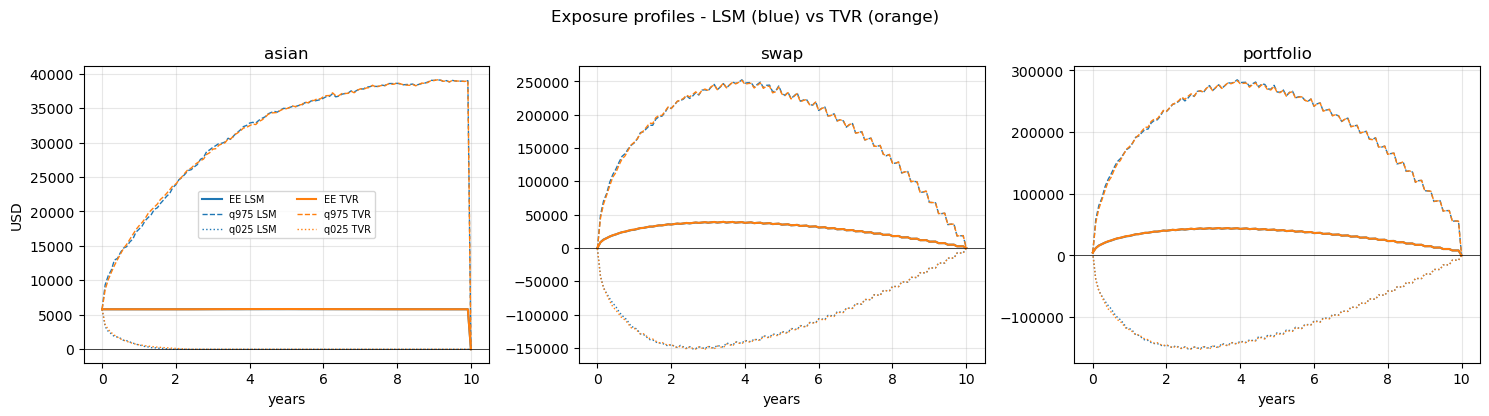

In [19]:
# EPE and quantile profiles (LSM vs TVR)
fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
colors = {"LSM": "C0", "TVR": "C1"}
styles = {"EE": "-", "q975": "--", "q025": ":"}
for ax, inst in zip(axs, ("asian", "swap", "portfolio")):
    for m in ("LSM", "TVR"):
        p = profiles(V[inst, m])
        for metric in ("EE", "q975", "q025"):
            ax.plot(grid, p[metric], color=colors[m], ls=styles[metric],
                     lw=1.5 if metric == "EE" else 1,
                     label=f"{metric} {m}")
    ax.axhline(0, color="k", lw=0.5); ax.set_title(inst); ax.set_xlabel("years"); ax.grid(alpha=0.3)
axs[0].set_ylabel("USD"); axs[0].legend(fontsize=7, ncol=2)
plt.suptitle("Exposure profiles - LSM (blue) vs TVR (orange)")
plt.tight_layout(); plt.show()

The figure shows the EE and the 2.5% / 97.5% quantile profiles for the option, the swap, and the netted portfolio, comparing LSM (blue) against TVR (orange). The swap's EE has the typical hump shape for an at-the-money swap: it rises as the uncertainty in $S_t$ accumulates, then falls as fewer cash flows remain to be exposed to. The Asian option's EE is almost flat, since averaging weakens the effect of volatility on the remaining payoff. It drops to zero at $T$, when the final cash flow settles. The portfolio profile is dominated by the swap. LSM and TVR give very similar results. 

## Validation

LSM and TVR only approximate $V_t$ through a finite-dimensional regression. We check them against benchmarks computed independently of the regression, using RMSE as metric. 

In [20]:
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

## IRS

Since $S_t$ follows a GBM, $\mathbb{E}[S_{t_i}\mid \mathcal F_t] = S_t\,e^{\mu(t_i-t)}$, which gives a closed-form value at any $t$:

$$V_t^{IRS} = N\tau \sum_{t_i > t} \frac{D(0,t_i)}{D(0,t)}\Big(S_t\, e^{\mu(t_i - t)} - K\Big).$$

In [21]:
def swap_analytic(S, j):
    """Closed form: E[S_ti | S_j] = S_j * e^(mu * (ti - tj)) -> the swap value is linear in S_j."""
    fut = cf_idx[cf_idx > j]
    fwd = S[:, j, None] * np.exp(MU * (grid[fut] - grid[j]))
    return NOTIONAL * tau * np.sum(D[fut] / D[j] * (fwd - K_SWAP), axis=1)

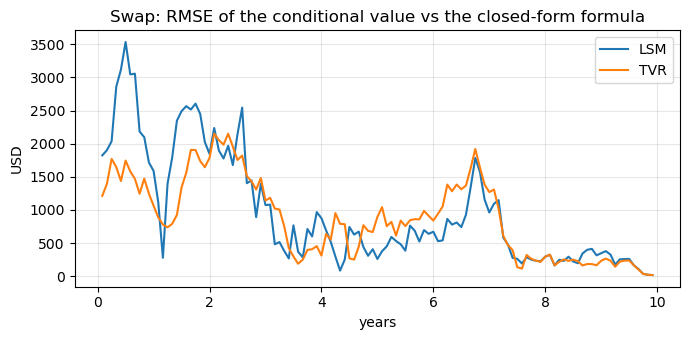

Swap: mean RMSE vs analytic  LSM = 967   TVR = 880


In [ ]:
# RMSE against the closed-form formula at each date
js = np.arange(1, n_steps)
err = {m: np.array([rmse(V["swap", m][:, j], swap_analytic(S, j)) for j in js]) for m in ("LSM", "TVR")}
plt.figure(figsize=(7, 3.5))
for m in err: plt.plot(grid[js], err[m], label=m)
plt.title("Swap: RMSE of the conditional value vs the closed-form formula"); plt.xlabel("years"); plt.ylabel("USD")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("Swap: mean RMSE vs analytic  LSM = %.0f   TVR = %.0f" % (err["LSM"].mean(), err["TVR"].mean()))

Both algorithms track the closed-form swap value closely, with a mean RMSE of under 3% of the peak EE.

### Asian option

The Asian option has no closed form - the average of correlated log-normal variables is not itself log-normal. As a benchmark, we instead use nested Monte Carlo: for states $(S_{t_j}, A_{t_j})$, we simulate many independent continuations to $T$ and average the resulting payoffs. 

In [23]:
def asian_nested(S, A, j, n_out=300, n_in=20_000, seed=0):
    """Nested MC: for n_out states (S_j, A_j), simulate n_in continuations to T."""
    rng = np.random.default_rng(seed)
    fut = cf_idx[cf_idx > j]
    n_done, n_tot = len(cf_idx) - len(fut), len(cf_idx)
    dts = np.diff(np.concatenate([[grid[j]], grid[fut]])) # steps from one fixing to the next
    out = np.empty(n_out)
    for k in range(n_out):
        Z = rng.standard_normal((n_in, len(fut)))
        logS = np.log(S[k, j]) + np.cumsum((MU - 0.5 * SIGMA**2) * dts + SIGMA * np.sqrt(dts) * Z, axis=1)
        A_T = (n_done * A[k, j] + np.exp(logS).sum(axis=1)) / n_tot
        out[k] = (NOTIONAL * np.maximum(A_T - K_ASIAN, 0)).mean() * D[-1] / D[j]
    return out


Asian option - RMSE vs nested MC (300 states x 20,000 inner paths):
 t= 2.5y LSM:      201 TVR:      194 (EE bench 4,911 | LSM 4,971 | TVR 4,965)
 t= 5.0y LSM:      195 TVR:      215 (EE bench 4,749 | LSM 4,783 | TVR 4,796)
 t= 7.5y LSM:      117 TVR:      113 (EE bench 4,660 | LSM 4,673 | TVR 4,675)


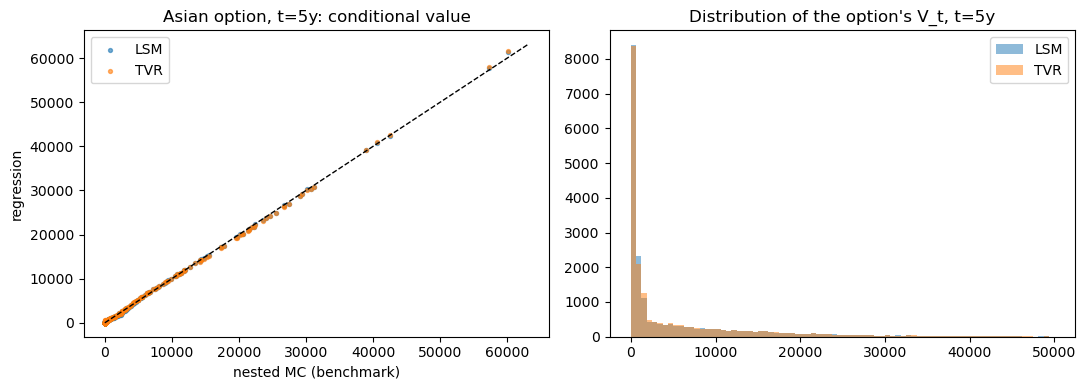

In [24]:
# nested MC at selected dates
print("\nAsian option - RMSE vs nested MC (300 states x 20,000 inner paths):")
bench = {}
for yr in (2.5, 5.0, 7.5):
    j = int(yr * STEPS_PY)
    bench[j] = asian_nested(S, A, j)
    vL, vT = V["asian", "LSM"][:300, j], V["asian", "TVR"][:300, j]
    print(f" t={yr:4.1f}y LSM: {rmse(vL, bench[j]):8.0f} TVR: {rmse(vT, bench[j]):8.0f}"
          f" (EE bench {np.maximum(bench[j],0).mean():,.0f} | LSM {np.maximum(vL,0).mean():,.0f} | TVR {np.maximum(vT,0).mean():,.0f})")

j5 = 5 * STEPS_PY
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for m, c in (("LSM", "C0"), ("TVR", "C1")):
    axs[0].scatter(bench[j5], V["asian", m][:300, j5], s=8, alpha=0.6, c=c, label=m)
lim = [0, bench[j5].max() * 1.05]
axs[0].plot(lim, lim, "k--", lw=1); axs[0].set_xlabel("nested MC (benchmark)"); axs[0].set_ylabel("regression")
axs[0].set_title("Asian option, t=5y: conditional value"); axs[0].legend()
axs[1].hist(V["asian", "LSM"][:, j5], 80, range=(0, 5e4), alpha=0.5, label="LSM"); axs[1].hist(V["asian", "TVR"][:, j5], 80, range=(0, 5e4), alpha=0.5, label="TVR")
axs[1].set_title("Distribution of the option's V_t, t=5y"); axs[1].legend()
plt.tight_layout(); plt.show()

RMSE against the nested-MC benchmark stays around 2-4% of the benchmark EE at all three tested dates, comparable to the swap's accuracy. The scatter plot confirms both regressions track the benchmark closely across the full range of states, not just on average.

## Convergence

LSM and TVR are Monte Carlo estimators, so their accuracy should improve as the number of simulated paths grows. Here we run both algorithms on the Asian option for an increasing number of paths and measure RMSE against the same nested-MC benchmark, to see how each method converges.

In [25]:
print("\nConvergence (Asian option): RMSE vs benchmark for a growing number of paths")
Sb, Ab = S[:300], A[:300]
for n in (1_000, 4_000, 16_000, 64_000):
    S2, A2, _, CF2 = simulate(n, SEED + 1)
    _, bL = value_LSM(CF2, basis_asian, S2, A2)
    _, bT = value_TVR(CF2, basis_asian, S2, A2)
    row = []
    for yr in (2.5, 5.0):
        j = int(yr * STEPS_PY); Phi_b = basis_asian(Sb, Ab, j)
        row.append(f"t={yr}y  LSM {rmse(np.maximum(Phi_b @ bL[j], 0), bench[j]):5.0f}  TVR {rmse(np.maximum(Phi_b @ bT[j], 0), bench[j]):5.0f}")
    print(f"  N={n:6d}   " + "   |   ".join(row))


Convergence (Asian option): RMSE vs benchmark for a growing number of paths
  N=  1000   t=2.5y  LSM  1082  TVR   837   |   t=5.0y  LSM  1420  TVR  1153
  N=  4000   t=2.5y  LSM   465  TVR   305   |   t=5.0y  LSM   226  TVR   275
  N= 16000   t=2.5y  LSM   281  TVR   220   |   t=5.0y  LSM   232  TVR   230
  N= 64000   t=2.5y  LSM   146  TVR   186   |   t=5.0y  LSM   212  TVR   218


RMSE falls for both methods when N increases. At low path counts TVR outperforms LSM, and the gap closes once enough paths are used, which is consistent with the bias-variance trade-off showed earlier: LSM's targets are noisy realized cash flows, TVR's lower-variance targets make it more robust in the small-sample regime.